In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the saved Project 5 data
adata = sc.read_h5ad('/Users/mac/Desktop/BIOINFORMATICS/Project 6_Survival_Analysis_Breast_Cancer/adata_scaled_checkpoint.h5ad')
print(adata)


AnnData object with n_obs × n_vars = 97710 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'subtype_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [2]:
#subset the data to cancer epithelial cells
adata_cancer = adata[adata.obs['celltype_major'] == 'Cancer Epithelial'].copy()
adata_cancer = adata_cancer[adata_cancer.obs['leiden'] != '25'].copy()
print(adata_cancer)


AnnData object with n_obs × n_vars = 22824 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'subtype_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [3]:
sc.tl.rank_genes_groups(adata_cancer, groupby='leiden', method='wilcoxon')

/Users/mac/miniconda3/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/mac/miniconda3/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/mac/miniconda3/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragme

In [4]:
result = sc.get.rank_genes_groups_df(
    adata_cancer,
    group=None,
    pval_cutoff=0.05,
    log2fc_min=0.5
)

print(result.shape)
print(result.head(20))


(26179, 6)
   group   names    scores  logfoldchanges         pvals     pvals_adj
0      0    RPL8  6.724164        0.910757  1.766027e-11  4.062697e-08
1      0   RPL41  6.627779        1.728925  3.407741e-11  6.254093e-08
2      0   RPS14  6.564580        1.166534  5.217951e-11  8.619186e-08
3      0   RPL35  6.516753        1.222958  7.184563e-11  1.017231e-07
4      0   RPS3A  6.463295        0.966787  1.024468e-10  1.324370e-07
5      0   RPL7A  6.332531        1.174364  2.411716e-10  2.655835e-07
6      0   RPS23  6.318851        0.970781  2.635149e-10  2.793761e-07
7      0   RPL36  6.296739        1.437676  3.039734e-10  2.943435e-07
8      0   RPL12  6.128653        1.333950  8.862652e-10  6.274125e-07
9      0   RPS24  6.088215        0.999459  1.141766e-09  7.544027e-07
10     0   RPS13  6.069682        0.908842  1.281642e-09  7.938970e-07
11     0   RPL28  6.063322        0.809487  1.333382e-09  8.090905e-07
12     0   EEF1D  5.857602        1.035192  4.695992e-09  2.072017

In [5]:
#Filter for clusters 9, 17, 7, and 16
clusters_of_interest = ['9', '17', '7', '16']
filtered_result = result[result['group'].isin(clusters_of_interest)]
print(filtered_result.shape)
print(filtered_result.head(20))

(7330, 6)
     group    names     scores  logfoldchanges  pvals  pvals_adj
2309     7  SCGB2A2  89.354485        7.570334    0.0        0.0
2310     7   S100A1  88.618599        5.156065    0.0        0.0
2311     7  S100A14  85.296631        3.572865    0.0        0.0
2312     7   CALML5  74.335396        3.861055    0.0        0.0
2313     7  SCGB1D2  72.624870        4.735648    0.0        0.0
2314     7   PYCARD  72.182755        2.656578    0.0        0.0
2315     7  SCGB2A1  71.776924        4.745977    0.0        0.0
2316     7      CLU  69.156006        3.109225    0.0        0.0
2317     7      PIP  67.590324        3.974004    0.0        0.0
2318     7    SSFA2  67.042702        3.504547    0.0        0.0
2319     7    RPS4X  66.261208        1.374065    0.0        0.0
2320     7  ZFP36L1  64.501411        2.031404    0.0        0.0
2321     7    KRT18  63.565269        1.640880    0.0        0.0
2322     7  MT-ATP8  63.481544        2.847503    0.0        0.0
2323     7     

In [6]:
#View each cluster sepeartely
for cluster in clusters_of_interest:
    print(f'\n--- Cluster {cluster} ---')
    cluster_df = filtered_result[filtered_result['group'] == cluster]
    print(cluster_df.head(20))


--- Cluster 9 ---
     group     names     scores  logfoldchanges  pvals  pvals_adj
6567     9      IDH2  87.089378        3.433263    0.0        0.0
6568     9     CRIP2  85.453186        2.764482    0.0        0.0
6569     9      CD24  84.994072        4.809701    0.0        0.0
6570     9       PKM  78.250107        2.678655    0.0        0.0
6571     9     MUCL1  77.698883        5.322139    0.0        0.0
6572     9      AIM1  76.970024        5.583250    0.0        0.0
6573     9      ATG5  75.388161        4.270288    0.0        0.0
6574     9    TMSB10  75.322464        1.827870    0.0        0.0
6575     9  IGKV3-15  70.497528        5.535632    0.0        0.0
6576     9  IGKV3-20  70.195610        4.759146    0.0        0.0
6577     9    AKR1A1  69.918625        2.420073    0.0        0.0
6578     9      P4HB  69.727753        1.990536    0.0        0.0
6579     9  C6orf203  69.553993        4.583124    0.0        0.0
6580     9      NGRN  68.372368        2.858918    0.0   

In [7]:
print(adata_cancer.obs[adata_cancer.obs['leiden'] == '17']['celltype_minor'].value_counts())


celltype_minor
Cancer Her2 SC     10
Cancer Basal SC     3
Cancer LumB SC      3
Cancer Cycling      2
Cancer LumA SC      0
Name: count, dtype: int64


In [8]:
print(adata_cancer.obs[adata_cancer.obs['leiden'] == '17'][['subtype', 'celltype_minor', 'celltype_subset']].value_counts())


subtype  celltype_minor   celltype_subset
TNBC     Cancer Her2 SC   Cancer Her2 SC     10
         Cancer Basal SC  Cancer Basal SC     3
         Cancer LumB SC   Cancer LumB SC      3
         Cancer Cycling   Cancer Cycling      2
Name: count, dtype: int64


In [9]:
print(adata_cancer.obs.groupby(['leiden', 'subtype']).size().unstack(fill_value=0))


subtype   ER+  HER2+  TNBC
leiden                    
0          35      3     5
1           0      0     2
2           3      1     0
3           1      0    10
4           4      2    49
5          27      2    50
7        4055    541     4
8        2968     71    10
9          76     80  3939
10          0      0    23
11          7     12  1833
12          2      0    10
13       2190      1     4
14          3      5  2116
16       2128      0     0
17          0      0    18
18          1      0     5
19          0      0     3
21          2      3   811
22          0      0   942
23          0      0     7
24          8    736    16


/var/folders/07/f2yy4z5s7j1b9s4fwrq5yt300000gn/T/ipykernel_1071/3105140256.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata_cancer.obs.groupby(['leiden', 'subtype']).size().unstack(fill_value=0))


In [10]:
#filter clusters to 11, 13, 14, 21, 22, and 24
clusters_of_interest_2 = ['11', '13', '14', '21', '22', '24']
filtered_result_2 = result[result['group'].isin(clusters_of_interest_2)]
print(filtered_result_2.shape)
print(filtered_result_2.head(20))

(14250, 6)
      group     names     scores  logfoldchanges  pvals  pvals_adj
10490    11    RPS27A  68.900864        2.599047    0.0        0.0
10491    11     HLA-B  66.711433        4.395401    0.0        0.0
10492    11       B2M  65.067581        3.054230    0.0        0.0
10493    11     HLA-A  63.681145        3.821366    0.0        0.0
10494    11    S100A4  63.547646        5.561666    0.0        0.0
10495    11   RARRES1  63.403549        6.075608    0.0        0.0
10496    11      SAA1  63.122036        7.839195    0.0        0.0
10497    11     RPS20  62.896446        3.756897    0.0        0.0
10498    11   TMEM123  62.852432        3.240334    0.0        0.0
10499    11     RPS17  61.346432        3.126675    0.0        0.0
10500    11   HLA-DRA  61.167370        4.992352    0.0        0.0
10501    11     RPL21  60.231945        2.076792    0.0        0.0
10502    11     CRYAB  59.924427        5.358956    0.0        0.0
10503    11     RPL13  59.484295        1.717343   

In [11]:

for cluster in ['11', '13', '14', '21', '22', '24']:
    print(f'\n--- Cluster {cluster} ---')
    cluster_df = filtered_result_2[filtered_result_2['group'] == cluster]
    print(cluster_df.head(10))



--- Cluster 11 ---
      group    names     scores  logfoldchanges  pvals  pvals_adj
10490    11   RPS27A  68.900864        2.599047    0.0        0.0
10491    11    HLA-B  66.711433        4.395401    0.0        0.0
10492    11      B2M  65.067581        3.054230    0.0        0.0
10493    11    HLA-A  63.681145        3.821366    0.0        0.0
10494    11   S100A4  63.547646        5.561666    0.0        0.0
10495    11  RARRES1  63.403549        6.075608    0.0        0.0
10496    11     SAA1  63.122036        7.839195    0.0        0.0
10497    11    RPS20  62.896446        3.756897    0.0        0.0
10498    11  TMEM123  62.852432        3.240334    0.0        0.0
10499    11    RPS17  61.346432        3.126675    0.0        0.0

--- Cluster 13 ---
      group     names     scores  logfoldchanges  pvals  pvals_adj
14453    13      IGKC  69.734612        4.533683    0.0        0.0
14454    13      CST3  66.484962        3.685846    0.0        0.0
14455    13     DHRS2  65.893860 

In [12]:
#Investigate cluster 13 further
print(adata_cancer.obs[adata_cancer.obs['leiden'] == '13'][['subtype', 'celltype_minor']].value_counts())


subtype  celltype_minor 
ER+      Cancer LumB SC     1993
         Cancer Cycling      187
         Cancer LumA SC        8
TNBC     Cancer LumB SC        2
ER+      Cancer Basal SC       1
         Cancer Her2 SC        1
HER2+    Cancer Cycling        1
TNBC     Cancer Basal SC       1
         Cancer Cycling        1
Name: count, dtype: int64


In [13]:
##download MSigDB hallmarks directly from the website
import urllib.request
urllib.request.urlretrieve(
    'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/h.all.v2023.2.Hs.symbols.gmt',
    'hallmarks.gmt'
)
print('Downloaded successfully')


Downloaded successfully


In [14]:
#load hallmarks gene sets from the downloaded file
hallmarks = {}
with open('hallmarks.gmt', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        name = parts[0]
        genes = set(parts[2:])
        hallmarks[name] = genes

print(f'Loaded {len(hallmarks)} hallmark gene sets')
print(list(hallmarks.keys())[:5])


Loaded 50 hallmark gene sets
['HALLMARK_ADIPOGENESIS', 'HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_ANDROGEN_RESPONSE', 'HALLMARK_ANGIOGENESIS', 'HALLMARK_APICAL_JUNCTION']


In [15]:
# Define relevant hallmarks for cancer stress response
relevant_hallmarks = [
    'HALLMARK_GLYCOLYSIS',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_HYPOXIA',
    'HALLMARK_APOPTOSIS',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'HALLMARK_INFLAMMATORY_RESPONSE',
    'HALLMARK_IL6_JAK_STAT3_SIGNALING',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_DNA_REPAIR',
    'HALLMARK_UNFOLDED_PROTEIN_RESPONSE'
]

# For each cluster, find genes that overlap with relevant hallmarks

clusters_of_interest = ['9', '11', '13', '14', '16', '21', '22', '24', '7']

for cluster in clusters_of_interest:
    cluster_genes = set(filtered_result[filtered_result['group'] == cluster]['names'].values)
    print(f'\n--- Cluster {cluster} ---')
    for hallmark in relevant_hallmarks:
        overlap = cluster_genes & hallmarks[hallmark]
        if len(overlap) > 0:
            print(f'{hallmark}: {overlap}')



--- Cluster 9 ---
HALLMARK_GLYCOLYSIS: {'HDLBP', 'ME1', 'AURKA', 'TPI1', 'ERO1A', 'KIF2A', 'DEPDC1', 'ZNF292', 'MPI', 'CLN6', 'CITED2', 'B4GALT4', 'AGRN', 'VEGFA', 'AKR1A1', 'CENPA', 'KIF20A', 'P4HA1', 'ANGPTL4', 'GMPPA', 'PMM2', 'CHPF', 'ADORA2B', 'ANKZF1', 'LCT', 'MIF', 'B3GAT3', 'EGLN3', 'PDK3', 'IDH1', 'VLDLR', 'ENO1', 'EFNA3', 'GALE', 'MDH2', 'SLC25A13', 'PKM', 'HMMR', 'PGAM1', 'GOT1', 'LDHA', 'ALDOA', 'SLC37A4', 'IL13RA1', 'TFF3', 'ISG20', 'STMN1', 'NASP', 'SDC1', 'PPIA', 'FAM162A', 'EGFR', 'LHPP', 'CLDN3', 'PGK1', 'SDC3', 'PGLS', 'CDK1', 'CHST1', 'B4GALT7', 'NSDHL', 'G6PD', 'AK4', 'DSC2'}
HALLMARK_OXIDATIVE_PHOSPHORYLATION: {'ECHS1', 'SDHB', 'HSD17B10', 'OXA1L', 'UQCRC1', 'BCKDHA', 'NDUFS7', 'AFG3L2', 'POR', 'MRPS22', 'COX7A2', 'FDX1', 'COX7B', 'SLC25A3', 'NDUFB4', 'MTX2', 'PDHA1', 'COX8A', 'GPX4', 'IMMT', 'DLST', 'MRPS12', 'IDH1', 'MFN2', 'MRPS11', 'MRPL11', 'HADHA', 'MDH2', 'TIMM50', 'ACAA2', 'OGDH', 'ATP6V0C', 'NDUFB7', 'UQCRFS1', 'PDP1', 'NDUFV1', 'IDH2', 'LDHA', 'AIFM1', '

In [16]:
all_results = pd.concat([filtered_result, filtered_result_2], ignore_index=True)
print(all_results['group'].unique())
print(all_results.shape)


['7', '9', '16', '17', '11', '13', '14', '21', '22', '24']
Categories (22, object): ['0', '1', '2', '3', ..., '21', '22', '23', '24']
(21580, 6)


In [17]:
for cluster in clusters_of_interest:
    cluster_genes = set(all_results[all_results['group'] == cluster]['names'].values)
    print(f'\n--- Cluster {cluster} ---')
    for hallmark in relevant_hallmarks:
        overlap = cluster_genes & hallmarks[hallmark]
        if len(overlap) > 0:
            print(f'{hallmark}: {overlap}')



--- Cluster 9 ---
HALLMARK_GLYCOLYSIS: {'HDLBP', 'ME1', 'AURKA', 'TPI1', 'ERO1A', 'KIF2A', 'DEPDC1', 'ZNF292', 'MPI', 'CLN6', 'CITED2', 'B4GALT4', 'AGRN', 'VEGFA', 'AKR1A1', 'CENPA', 'KIF20A', 'P4HA1', 'ANGPTL4', 'GMPPA', 'PMM2', 'CHPF', 'ADORA2B', 'ANKZF1', 'LCT', 'MIF', 'B3GAT3', 'EGLN3', 'PDK3', 'IDH1', 'VLDLR', 'ENO1', 'EFNA3', 'GALE', 'MDH2', 'SLC25A13', 'PKM', 'HMMR', 'PGAM1', 'GOT1', 'LDHA', 'ALDOA', 'SLC37A4', 'IL13RA1', 'TFF3', 'ISG20', 'STMN1', 'NASP', 'SDC1', 'PPIA', 'FAM162A', 'EGFR', 'LHPP', 'CLDN3', 'PGK1', 'SDC3', 'PGLS', 'CDK1', 'CHST1', 'B4GALT7', 'NSDHL', 'G6PD', 'AK4', 'DSC2'}
HALLMARK_OXIDATIVE_PHOSPHORYLATION: {'ECHS1', 'SDHB', 'HSD17B10', 'OXA1L', 'UQCRC1', 'BCKDHA', 'NDUFS7', 'AFG3L2', 'POR', 'MRPS22', 'COX7A2', 'FDX1', 'COX7B', 'SLC25A3', 'NDUFB4', 'MTX2', 'PDHA1', 'COX8A', 'GPX4', 'IMMT', 'DLST', 'MRPS12', 'IDH1', 'MFN2', 'MRPS11', 'MRPL11', 'HADHA', 'MDH2', 'TIMM50', 'ACAA2', 'OGDH', 'ATP6V0C', 'NDUFB7', 'UQCRFS1', 'PDP1', 'NDUFV1', 'IDH2', 'LDHA', 'AIFM1', '

In [18]:
# Count how many relevant hallmarks each gene appears in per cluster
for cluster in ['9', '11', '13', '14', '16', '21', '22', '24', '7']:
    cluster_genes = set(all_results[all_results['group'] == cluster]['names'].values)
    gene_hallmark_count = {}
    
    for hallmark in relevant_hallmarks:
        overlap = cluster_genes & hallmarks[hallmark]
        for gene in overlap:
            gene_hallmark_count[gene] = gene_hallmark_count.get(gene, 0) + 1
    
    # Show top genes appearing in most hallmarks
    sorted_genes = sorted(gene_hallmark_count.items(), key=lambda x: x[1], reverse=True)
    print(f'\n--- Cluster {cluster} --- Top multi-Hallmark genes')
    print(sorted_genes[:10])



--- Cluster 9 --- Top multi-Hallmark genes
[('VEGFA', 5), ('JUN', 5), ('CDKN1A', 4), ('ATF3', 4), ('ERO1A', 3), ('ADORA2B', 3), ('LDHA', 3), ('ISG20', 3), ('GPX4', 3), ('KLF6', 3)]

--- Cluster 11 --- Top multi-Hallmark genes
[('CD44', 5), ('VEGFA', 5), ('DCN', 4), ('PLAUR', 4), ('CHST2', 3), ('IGFBP3', 3), ('IRS2', 3), ('TGFBI', 3), ('KDELR3', 3), ('ISG20', 3)]

--- Cluster 13 --- Top multi-Hallmark genes
[('CD44', 5), ('ENO2', 4), ('IER3', 4), ('IRF1', 4), ('STC2', 3), ('IRS2', 3), ('HSPA5', 3), ('TPBG', 3), ('SDC4', 3), ('BTG2', 3)]

--- Cluster 14 --- Top multi-Hallmark genes
[('CASP6', 3), ('DDIT4', 3), ('CD69', 3), ('FAS', 3), ('RELA', 3), ('CXCL10', 3), ('TPI1', 2), ('SDHC', 2), ('UGP2', 2), ('CXCR4', 2)]

--- Cluster 16 --- Top multi-Hallmark genes
[('CD44', 5), ('JUN', 5), ('IER3', 4), ('GPC1', 3), ('STC2', 3), ('CASP6', 3), ('TPBG', 3), ('RHOB', 3), ('BTG2', 3), ('GADD45B', 3)]

--- Cluster 21 --- Top multi-Hallmark genes
[('IL6', 6), ('CD44', 5), ('DCN', 4), ('CDKN1A', 4), 

In [19]:
# Final validated gene signatures
tnbc_signature = {
    'cluster_9_metabolism': ['VEGFA', 'ATF3', 'LDHA', 'ERO1A', 'PKM'],
    'cluster_11_immune': ['CD44', 'PLAUR', 'DCN', 'IGFBP3', 'TPBG'],
    'cluster_14_glycolytic': ['DDIT4', 'RELA', 'FAS', 'CXCL10', 'LDHB'],
    'cluster_21_emt': ['IL6', 'SERPINE1', 'IL1B', 'CDKN1A', 'COL5A1'],
    'cluster_22_inflammatory': ['PLAUR', 'DDIT4', 'ERO1A', 'CEBPB', 'F3']
}

erplus_signature = {
    'cluster_7_luminal': ['JUN', 'CDKN1A', 'IRF1', 'GADD45B', 'DDIT4'],
    'cluster_13_luminalB': ['ENO2', 'IRF1', 'HSPA5', 'IER3', 'BTG2'],
    'cluster_16_endocrine': ['CD44', 'IER3', 'GADD45B', 'RHOB', 'STC2']
}

her2_signature = {
    'cluster_24_metabolic': ['CASP6', 'SAT1', 'ENO1', 'IDH1', 'SOD1']
}

# Flat lists for analysis
tnbc_genes = [g for genes in tnbc_signature.values() for g in genes]
erplus_genes = [g for genes in erplus_signature.values() for g in genes]
her2_genes = [g for genes in her2_signature.values() for g in genes]

print('TNBC signature:', tnbc_genes)
print('ER+ signature:', erplus_genes)
print('HER2+ signature:', her2_genes)
print(f'\nTotal genes: TNBC={len(tnbc_genes)}, ER+={len(erplus_genes)}, HER2+={len(her2_genes)}')


TNBC signature: ['VEGFA', 'ATF3', 'LDHA', 'ERO1A', 'PKM', 'CD44', 'PLAUR', 'DCN', 'IGFBP3', 'TPBG', 'DDIT4', 'RELA', 'FAS', 'CXCL10', 'LDHB', 'IL6', 'SERPINE1', 'IL1B', 'CDKN1A', 'COL5A1', 'PLAUR', 'DDIT4', 'ERO1A', 'CEBPB', 'F3']
ER+ signature: ['JUN', 'CDKN1A', 'IRF1', 'GADD45B', 'DDIT4', 'ENO2', 'IRF1', 'HSPA5', 'IER3', 'BTG2', 'CD44', 'IER3', 'GADD45B', 'RHOB', 'STC2']
HER2+ signature: ['CASP6', 'SAT1', 'ENO1', 'IDH1', 'SOD1']

Total genes: TNBC=25, ER+=15, HER2+=5


In [20]:


# File 1 — Gene expression
expression = pd.read_csv('/Users/mac/Desktop/BIOINFORMATICS/Project 6_Survival_Analysis_Breast_Cancer/TCGA.BRCA.sampleMap_HiSeqV2.gz', 
                          sep='\t', index_col=0, compression='gzip')

# File 2 — Survival data
survival = pd.read_csv('/Users/mac/Desktop/BIOINFORMATICS/Project 6_Survival_Analysis_Breast_Cancer/survival_data.tsv', sep='\t')

# File 3 — Phenotype/subtype
phenotype = pd.read_csv('/Users/mac/Desktop/BIOINFORMATICS/Project 6_Survival_Analysis_Breast_Cancer/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix', sep='\t')

print('Expression shape:', expression.shape)
print('Survival shape:', survival.shape)
print('Phenotype shape:', phenotype.shape)

print('\nSurvival columns:', survival.columns.tolist())
print('Phenotype columns:', phenotype.columns.tolist())


Expression shape: (20530, 1218)
Survival shape: (1236, 11)
Phenotype shape: (1247, 194)

Survival columns: ['sample', '_PATIENT', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']
Phenotype columns: ['sampleID', 'AJCC_Stage_nature2012', 'Age_at_Initial_Pathologic_Diagnosis_nature2012', 'CN_Clusters_nature2012', 'Converted_Stage_nature2012', 'Days_to_Date_of_Last_Contact_nature2012', 'Days_to_date_of_Death_nature2012', 'ER_Status_nature2012', 'Gender_nature2012', 'HER2_Final_Status_nature2012', 'Integrated_Clusters_no_exp__nature2012', 'Integrated_Clusters_unsup_exp__nature2012', 'Integrated_Clusters_with_PAM50__nature2012', 'Metastasis_Coded_nature2012', 'Metastasis_nature2012', 'Node_Coded_nature2012', 'Node_nature2012', 'OS_Time_nature2012', 'OS_event_nature2012', 'PAM50Call_RNAseq', 'PAM50_mRNA_nature2012', 'PR_Status_nature2012', 'RPPA_Clusters_nature2012', 'SigClust_Intrinsic_mRNA_nature2012', 'SigClust_Unsupervised_mRNA_nature2012', 'Survival_

In [21]:
print(phenotype['PAM50Call_RNAseq'].value_counts())


PAM50Call_RNAseq
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64


In [22]:
print(survival['OS'].value_counts())
print(survival['OS.time'].describe())


OS
0    1034
1     202
Name: count, dtype: int64
count    1235.000000
mean     1274.348178
std      1165.122183
min         0.000000
25%       477.000000
50%       921.000000
75%      1759.000000
max      8605.000000
Name: OS.time, dtype: float64


In [23]:
# Transpose expression so patients are rows
expr_T = expression.T
expr_T.index.name = 'sample'
expr_T = expr_T.reset_index()

# Merge expression with survival
merged = expr_T.merge(survival[['sample', 'OS', 'OS.time']], 
                      on='sample', how='inner')

# Merge with phenotype
merged = merged.merge(
    phenotype[['sampleID', 'PAM50Call_RNAseq', 
               'age_at_initial_pathologic_diagnosis',
               'pathologic_stage']],
    left_on='sample', right_on='sampleID', how='inner')

print(merged.shape)
print(merged['PAM50Call_RNAseq'].value_counts())


(1215, 20537)
PAM50Call_RNAseq
LumA      433
LumB      194
Basal     141
Normal    118
Her2       67
Name: count, dtype: int64


In [24]:
tnbc_genes_unique = list(dict.fromkeys(tnbc_genes))
print(f'Original: {len(tnbc_genes)} genes')
print(f'After deduplication: {len(tnbc_genes_unique)} genes')
print(tnbc_genes_unique)


Original: 25 genes
After deduplication: 22 genes
['VEGFA', 'ATF3', 'LDHA', 'ERO1A', 'PKM', 'CD44', 'PLAUR', 'DCN', 'IGFBP3', 'TPBG', 'DDIT4', 'RELA', 'FAS', 'CXCL10', 'LDHB', 'IL6', 'SERPINE1', 'IL1B', 'CDKN1A', 'COL5A1', 'CEBPB', 'F3']


In [25]:
# Check which of our TNBC genes are actually in the expression data
missing_genes = [g for g in tnbc_genes_unique if g not in merged.columns]
found_genes = [g for g in tnbc_genes_unique if g in merged.columns]

print('Missing genes:', missing_genes)
print('Found genes:', found_genes)
print(f'{len(found_genes)} out of {len(tnbc_genes_unique)} found')


Missing genes: ['ERO1A', 'PKM']
Found genes: ['VEGFA', 'ATF3', 'LDHA', 'CD44', 'PLAUR', 'DCN', 'IGFBP3', 'TPBG', 'DDIT4', 'RELA', 'FAS', 'CXCL10', 'LDHB', 'IL6', 'SERPINE1', 'IL1B', 'CDKN1A', 'COL5A1', 'CEBPB', 'F3']
20 out of 22 found


In [26]:
# Search for similar names in expression columns
for gene in ['ERO1A', 'PKM']:
    matches = [col for col in merged.columns if gene in col]
    print(f'{gene} matches:', matches)


ERO1A matches: []
PKM matches: ['PKMYT1', 'PKM2']


In [27]:
# Replace PKM with PKM2 and remove ERO1A
tnbc_genes_unique = [g for g in tnbc_genes_unique if g not in ['PKM', 'ERO1A']]
tnbc_genes_unique.append('PKM2')

print('Final TNBC genes:', tnbc_genes_unique)
print('Total:', len(tnbc_genes_unique))


Final TNBC genes: ['VEGFA', 'ATF3', 'LDHA', 'CD44', 'PLAUR', 'DCN', 'IGFBP3', 'TPBG', 'DDIT4', 'RELA', 'FAS', 'CXCL10', 'LDHB', 'IL6', 'SERPINE1', 'IL1B', 'CDKN1A', 'COL5A1', 'CEBPB', 'F3', 'PKM2']
Total: 21


In [28]:
from scipy.stats import zscore

#score each patient of TNBC signature
tnbc_expr = merged[tnbc_genes_unique]
#z-score  normalise each gene
tnbc_scores = zscore(tnbc_expr, axis=0)
#calculate mean score across all genes for each patient
tnbc_mean_scores = tnbc_scores.mean(axis=1)
tnbc_mean_scores = pd.Series(tnbc_scores.mean(axis=1), index=merged.index)
print(tnbc_mean_scores.describe())


count    1.215000e+03
mean     7.529414e-17
std      4.261990e-01
min     -1.567696e+00
25%     -2.562694e-01
50%      1.177054e-02
75%      2.882456e-01
max      1.641366e+00
dtype: float64


In [29]:
# Check ER+ genes
erplus_genes_unique = list(dict.fromkeys(erplus_genes))
missing_erplus = [g for g in erplus_genes_unique if g not in merged.columns]
found_erplus = [g for g in erplus_genes_unique if g in merged.columns]
print('ER+ missing:', missing_erplus)
print('ER+ found:', len(found_erplus))

# Check HER2+ genes
her2_genes_unique = list(dict.fromkeys(her2_genes))
missing_her2 = [g for g in her2_genes_unique if g not in merged.columns]
found_her2 = [g for g in her2_genes_unique if g in merged.columns]
print('HER2+ missing:', missing_her2)
print('HER2+ found:', len(found_her2))


ER+ missing: []
ER+ found: 12
HER2+ missing: []
HER2+ found: 5


In [30]:
# ER+ signature score
erplus_expr = merged[erplus_genes_unique]
erplus_scores = zscore(erplus_expr, axis=0)
erplus_mean_scores = pd.Series(erplus_scores.mean(axis=1), index=merged.index)
print('ER+ scores:')
print(erplus_mean_scores.describe())

# HER2+ signature score
her2_expr = merged[her2_genes_unique]
her2_scores = zscore(her2_expr, axis=0)
her2_mean_scores = pd.Series(her2_scores.mean(axis=1), index=merged.index)
print('\nHER2+ scores:')
print(her2_mean_scores.describe())


ER+ scores:
count    1.215000e+03
mean    -6.816678e-17
std      4.009620e-01
min     -1.472456e+00
25%     -2.635172e-01
50%     -4.859586e-03
75%      2.653807e-01
max      1.373614e+00
dtype: float64

HER2+ scores:
count    1.215000e+03
mean     2.573159e-16
std      5.065768e-01
min     -2.148554e+00
25%     -3.408049e-01
50%     -4.666789e-02
75%      3.041989e-01
max      2.355869e+00
dtype: float64


In [31]:
merged['tnbc_score'] = tnbc_mean_scores
merged['erplus_score'] = erplus_mean_scores
merged['her2_score'] = her2_mean_scores

print(merged[['tnbc_score', 'erplus_score', 'her2_score']].describe())


         tnbc_score  erplus_score    her2_score
count  1.215000e+03  1.215000e+03  1.215000e+03
mean   7.529414e-17 -6.816678e-17  2.573159e-16
std    4.261990e-01  4.009620e-01  5.065768e-01
min   -1.567696e+00 -1.472456e+00 -2.148554e+00
25%   -2.562694e-01 -2.635172e-01 -3.408049e-01
50%    1.177054e-02 -4.859586e-03 -4.666789e-02
75%    2.882456e-01  2.653807e-01  3.041989e-01
max    1.641366e+00  1.373614e+00  2.355869e+00


In [32]:
# Stratify patients into high vs low groups based on median score
merged['tnbc_group'] = (merged['tnbc_score'] > merged['tnbc_score'].median()).astype(int)
merged['erplus_group'] = (merged['erplus_score'] > merged['erplus_score'].median()).astype(int)
merged['her2_group'] = (merged['her2_score'] > merged['her2_score'].median()).astype(int)

# 1 = high signature, 0 = low signature
print(merged['tnbc_group'].value_counts())
print(merged['erplus_group'].value_counts())
print(merged['her2_group'].value_counts())



tnbc_group
0    608
1    607
Name: count, dtype: int64
erplus_group
0    608
1    607
Name: count, dtype: int64
her2_group
0    608
1    607
Name: count, dtype: int64


In [33]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt


In [34]:
#KM curve - all patients, TNBC signature
# Split into high and low groups
high = merged[merged['tnbc_group'] == 1]
low = merged[merged['tnbc_group'] == 0]

# Remove patients with missing survival data
merged_clean = merged.dropna(subset=['OS', 'OS.time'])
print(f'Patients after removing NaN: {merged_clean.shape[0]}')

# Check how many NaN were removed
print(f'Removed: {merged.shape[0] - merged_clean.shape[0]} patients')

#redo split after removing NaN
high = merged_clean[merged_clean['tnbc_group'] == 1]
low = merged_clean[merged_clean['tnbc_group'] == 0]

print('High group:', len(high))
print('Low group:', len(low))




Patients after removing NaN: 1214
Removed: 1 patients
High group: 606
Low group: 608


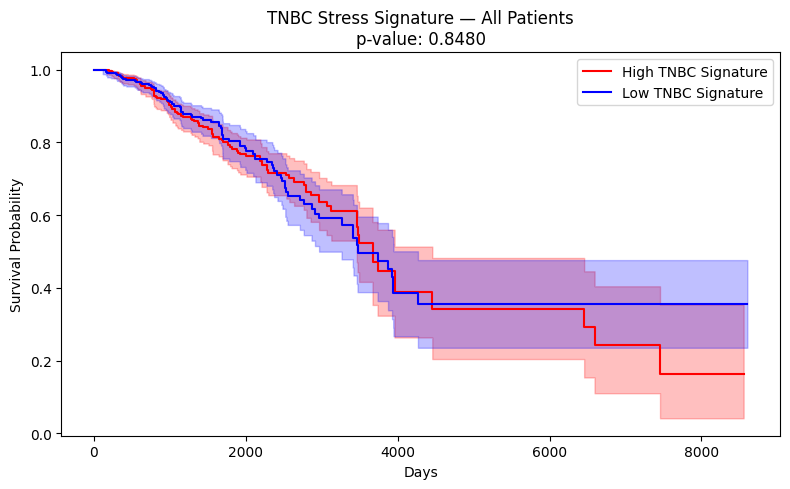

Log-rank p-value: 0.8480


In [35]:
# Split into high and low groups
high = merged_clean[merged_clean['tnbc_group'] == 1]
low = merged_clean[merged_clean['tnbc_group'] == 0]

# Fit KM curves
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_high.fit(high['OS.time'], event_observed=high['OS'], label='High TNBC Signature')
kmf_low.fit(low['OS.time'], event_observed=low['OS'], label='Low TNBC Signature')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
kmf_high.plot_survival_function(ax=ax, color='red')
kmf_low.plot_survival_function(ax=ax, color='blue')

# Log-rank test
results = logrank_test(high['OS.time'], low['OS.time'],
                       event_observed_A=high['OS'],
                       event_observed_B=low['OS'])

ax.set_title(f'TNBC Stress Signature — All Patients\np-value: {results.p_value:.4f}')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('KM_TNBC_all_patients.png', dpi=300)
plt.show()

print(f'Log-rank p-value: {results.p_value:.4f}')


In [36]:
# Filter Basal patients
basal = merged_clean[merged_clean['PAM50Call_RNAseq'] == 'Basal'].copy()
print('Basal patients:', len(basal))

# Recalculate high/low within Basal only
basal_median = basal['tnbc_score'].median()
basal_high = basal[basal['tnbc_score'] > basal_median]
basal_low = basal[basal['tnbc_score'] <= basal_median]

print('Basal high:', len(basal_high))
print('Basal low:', len(basal_low))


Basal patients: 141
Basal high: 70
Basal low: 71


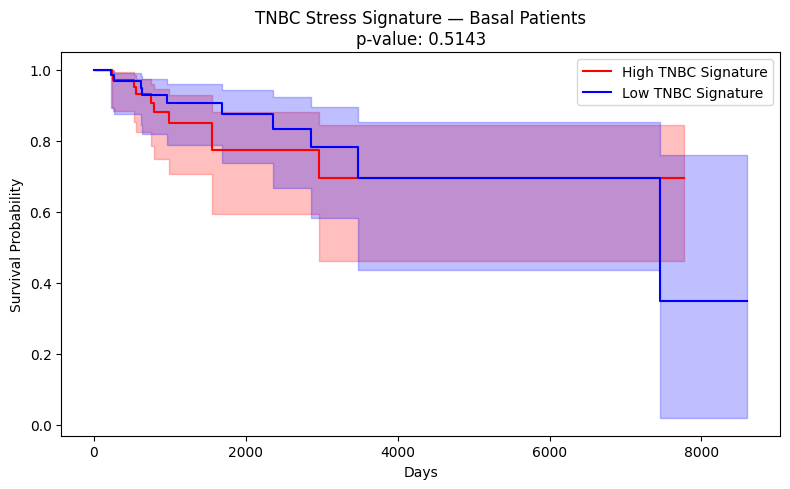

Log-rank p-value (Basal): 0.5143


In [37]:
kmf_basal_high = KaplanMeierFitter()
kmf_basal_low = KaplanMeierFitter()

kmf_basal_high.fit(basal_high['OS.time'], 
                   event_observed=basal_high['OS'], 
                   label='High TNBC Signature')

kmf_basal_low.fit(basal_low['OS.time'], 
                  event_observed=basal_low['OS'], 
                  label='Low TNBC Signature')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
kmf_basal_high.plot_survival_function(ax=ax, color='red')
kmf_basal_low.plot_survival_function(ax=ax, color='blue')

# Log-rank test
results_basal = logrank_test(
    basal_high['OS.time'], basal_low['OS.time'],
    event_observed_A=basal_high['OS'],
    event_observed_B=basal_low['OS'])

ax.set_title(f'TNBC Stress Signature — Basal Patients\np-value: {results_basal.p_value:.4f}')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('KM_TNBC_basal_patients.png', dpi=300)
plt.show()

print(f'Log-rank p-value (Basal): {results_basal.p_value:.4f}')


In [38]:
# TESTING Cluster 9 genes only
cluster9_genes = ['VEGFA', 'ATF3', 'LDHA', 'PKM2', 'IDH2']

# Check all genes exist
missing = [g for g in cluster9_genes if g not in merged_clean.columns]
print('Missing:', missing)


Missing: []


In [39]:
# Score Cluster 9 only
cluster9_expr = merged_clean[cluster9_genes]
cluster9_scores = zscore(cluster9_expr, axis=0)
cluster9_mean_scores = pd.Series(cluster9_scores.mean(axis=1), index=merged_clean.index)

# Add to merged_clean
merged_clean['cluster9_score'] = cluster9_mean_scores

# Filter Basal patients
basal = merged_clean[merged_clean['PAM50Call_RNAseq'] == 'Basal'].copy()

# Split by Cluster 9 score median within Basal only
basal_median_c9 = basal['cluster9_score'].median()
basal_high_c9 = basal[basal['cluster9_score'] > basal_median_c9]
basal_low_c9 = basal[basal['cluster9_score'] <= basal_median_c9]

print('Basal high:', len(basal_high_c9))
print('Basal low:', len(basal_low_c9))


Basal high: 70
Basal low: 71


/var/folders/07/f2yy4z5s7j1b9s4fwrq5yt300000gn/T/ipykernel_1071/3020200921.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean['cluster9_score'] = cluster9_mean_scores


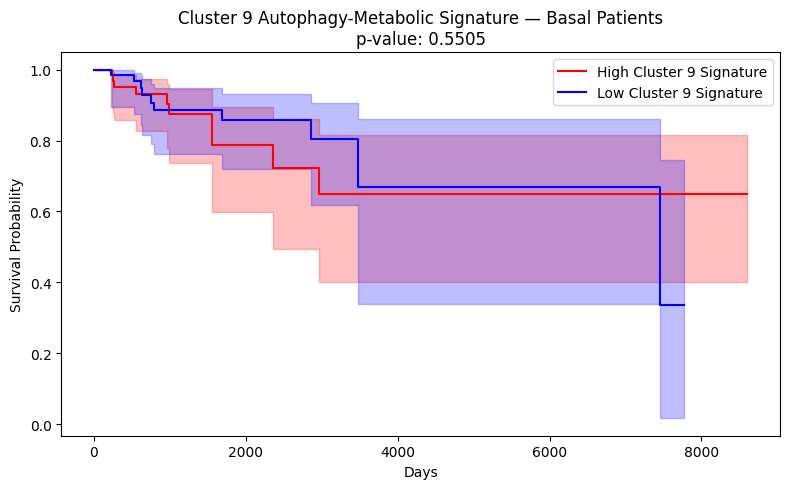

Log-rank p-value (Cluster 9 Basal): 0.5505


In [40]:
kmf_high_c9 = KaplanMeierFitter()
kmf_low_c9 = KaplanMeierFitter()

kmf_high_c9.fit(basal_high_c9['OS.time'],
                event_observed=basal_high_c9['OS'],
                label='High Cluster 9 Signature')

kmf_low_c9.fit(basal_low_c9['OS.time'],
               event_observed=basal_low_c9['OS'],
               label='Low Cluster 9 Signature')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
kmf_high_c9.plot_survival_function(ax=ax, color='red')
kmf_low_c9.plot_survival_function(ax=ax, color='blue')

# Log-rank test
results_c9 = logrank_test(
    basal_high_c9['OS.time'], basal_low_c9['OS.time'],
    event_observed_A=basal_high_c9['OS'],
    event_observed_B=basal_low_c9['OS'])

ax.set_title(f'Cluster 9 Autophagy-Metabolic Signature — Basal Patients\np-value: {results_c9.p_value:.4f}')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('KM_cluster9_basal.png', dpi=300)
plt.show()

print(f'Log-rank p-value (Cluster 9 Basal): {results_c9.p_value:.4f}')


In [41]:
print(survival.columns.tolist())
print(survival.head())


['sample', '_PATIENT', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']
            sample      _PATIENT  OS  OS.time  DSS  DSS.time  DFI  DFI.time  \
0  TCGA-3C-AAAU-01  TCGA-3C-AAAU   0   4047.0  0.0    4047.0  1.0    1808.0   
1  TCGA-3C-AALI-01  TCGA-3C-AALI   0   4005.0  0.0    4005.0  0.0    4005.0   
2  TCGA-3C-AALJ-01  TCGA-3C-AALJ   0   1474.0  0.0    1474.0  0.0    1474.0   
3  TCGA-3C-AALK-01  TCGA-3C-AALK   0   1448.0  0.0    1448.0  NaN       NaN   
4  TCGA-4H-AAAK-01  TCGA-4H-AAAK   0    348.0  0.0     348.0  0.0     348.0   

   PFI  PFI.time Redaction  
0    1    1808.0       NaN  
1    0    4005.0       NaN  
2    0    1474.0       NaN  
3    0    1448.0       NaN  
4    0     348.0       NaN  


In [42]:
# Re-merge adding DFI and PFI columns
merged_clean = merged_clean.merge(
    survival[['sample', 'DFI', 'DFI.time', 'PFI', 'PFI.time']],
    on='sample',
    how='left'
)

print(merged_clean[['OS', 'OS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time']].head())
print('\nDFI value counts:')
print(merged_clean['DFI'].value_counts())


   OS  OS.time  DFI  DFI.time  PFI  PFI.time
0   1    322.0  NaN       NaN    1     301.0
1   0    502.0  1.0     431.0    1     431.0
2   0   2255.0  1.0    1709.0    1    1709.0
3   0   2365.0  0.0    2365.0    0    2365.0
4   1    943.0  0.0     943.0    0     943.0

DFI value counts:
DFI
0.0    946
1.0     91
Name: count, dtype: int64


In [43]:
# Recreate basal with PFI columns included
basal = merged_clean[merged_clean['PAM50Call_RNAseq'] == 'Basal'].copy()

# Recalculate split
basal_median_c9 = basal['cluster9_score'].median()
basal_high_c9 = basal[basal['cluster9_score'] > basal_median_c9]
basal_low_c9 = basal[basal['cluster9_score'] <= basal_median_c9]

print('Basal patients:', len(basal))
print('PFI columns present:', 'PFI.time' in basal.columns)


Basal patients: 141
PFI columns present: True


In [44]:
print(merged_clean['DFI'].value_counts())
print(merged_clean['DFI.time'].describe())
# DFI analysis for Cluster 9 in Basal patients

DFI
0.0    946
1.0     91
Name: count, dtype: int64
count    1037.000000
mean     1172.677917
std      1075.840902
min         0.000000
25%       446.000000
50%       803.000000
75%      1611.000000
max      8556.000000
Name: DFI.time, dtype: float64


In [45]:
print(merged_clean['PFI'].value_counts())
print(merged_clean['PFI.time'].describe())


PFI
0    1043
1     171
Name: count, dtype: int64
count    1214.000000
mean     1188.255354
std      1067.313116
min         0.000000
25%       446.250000
50%       835.500000
75%      1628.250000
max      8556.000000
Name: PFI.time, dtype: float64


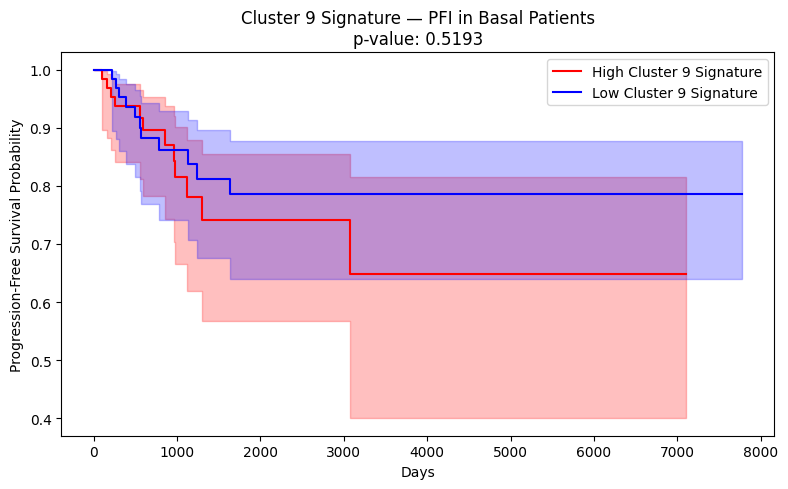

Log-rank p-value (Cluster 9 PFI Basal): 0.5193


In [46]:
#KM curve - PFI for Cluster 9 in Basal patients
# Split by Cluster 9 score median within Basal only
basal_median_c9 = basal['cluster9_score'].median()
basal_high_c9 = basal[basal['cluster9_score'] > basal_median_c9]
basal_low_c9 = basal[basal['cluster9_score'] <= basal_median_c9]    
kmf_high_c9_pfi = KaplanMeierFitter()
kmf_low_c9_pfi = KaplanMeierFitter()
kmf_high_c9_pfi.fit(basal_high_c9['PFI.time'],
                    event_observed=basal_high_c9['PFI'],
                    label='High Cluster 9 Signature')
kmf_low_c9_pfi.fit(basal_low_c9['PFI.time'],
                     event_observed=basal_low_c9['PFI'],    
                        label='Low Cluster 9 Signature')    
# Plot
fig, ax = plt.subplots(figsize=(8, 5))
kmf_high_c9_pfi.plot_survival_function(ax=ax, color='red')
kmf_low_c9_pfi.plot_survival_function(ax=ax, color='blue')
# Log-rank test
results_c9_pfi = logrank_test(
    basal_high_c9['PFI.time'], basal_low_c9['PFI.time'],
    event_observed_A=basal_high_c9['PFI'],
    event_observed_B=basal_low_c9['PFI'])
ax.set_title(f'Cluster 9 Signature — PFI in Basal Patients\np-value: {results_c9_pfi.p_value:.4f}')
ax.set_xlabel('Days')
ax.set_ylabel('Progression-Free Survival Probability')
plt.tight_layout()  
plt.savefig('KM_cluster9_basal_PFI.png', dpi=300)
plt.show()
print(f'Log-rank p-value (Cluster 9 PFI Basal): {results_c9_pfi.p_value:.4f}')


TCGA LumA patients: 433
Missing genes: []
High: 216 Low: 217


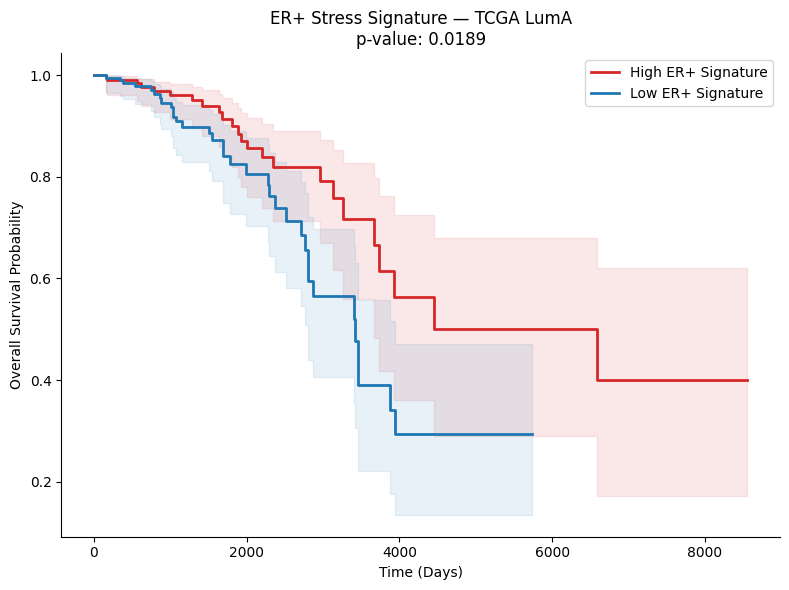

TCGA LumA p-value: 0.0189


In [47]:
# ============================================
# TCGA LumA - Complete ER+ Signature Analysis
# ============================================

# Filter LumA patients
luma = merged_clean[merged_clean['PAM50Call_RNAseq'] == 'LumA'].copy()
print('TCGA LumA patients:', len(luma))

# Check genes
missing = [g for g in erplus_genes_unique if g not in merged_clean.columns]
print('Missing genes:', missing)

# Score
luma_expr = luma[erplus_genes_unique]
luma_scores = zscore(luma_expr, axis=0)
luma['erplus_score'] = pd.Series(luma_scores.mean(axis=1), index=luma.index)

# Split
luma_high = luma[luma['erplus_score'] > luma['erplus_score'].median()]
luma_low = luma[luma['erplus_score'] <= luma['erplus_score'].median()]
print('High:', len(luma_high), 'Low:', len(luma_low))

# KM curve
kmf_luma_high = KaplanMeierFitter()
kmf_luma_low = KaplanMeierFitter()
kmf_luma_high.fit(luma_high['OS.time'], event_observed=luma_high['OS'], label='High ER+ Signature')
kmf_luma_low.fit(luma_low['OS.time'], event_observed=luma_low['OS'], label='Low ER+ Signature')

fig, ax = plt.subplots(figsize=(8, 6))
kmf_luma_high.plot_survival_function(ax=ax, color='#D62728', linewidth=2, ci_alpha=0.1)
kmf_luma_low.plot_survival_function(ax=ax, color='#1F77B4', linewidth=2, ci_alpha=0.1)

results_luma = logrank_test(
    luma_high['OS.time'], luma_low['OS.time'],
    event_observed_A=luma_high['OS'],
    event_observed_B=luma_low['OS'])

ax.set_title(f'ER+ Stress Signature — TCGA LumA\np-value: {results_luma.p_value:.4f}')
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Overall Survival Probability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('KM_TCGA_LumA.png', dpi=300)
plt.show()
print(f'TCGA LumA p-value: {results_luma.p_value:.4f}')


In [48]:
from lifelines import CoxPHFitter

# Prepare LumA Cox data
cox_data = luma[['OS.time', 'OS', 'erplus_score', 
                  'age_at_initial_pathologic_diagnosis',
                  'pathologic_stage']].copy()

# Clean - remove NaN
cox_data = cox_data.dropna()

# Encode stage as numeric
stage_map = {'Stage I': 1, 'Stage IA': 1, 'Stage IB': 1,
             'Stage II': 2, 'Stage IIA': 2, 'Stage IIB': 2,
             'Stage III': 3, 'Stage IIIA': 3, 'Stage IIIB': 3, 
             'Stage IIIC': 3, 'Stage IV': 4}
cox_data['stage_numeric'] = cox_data['pathologic_stage'].map(stage_map)
cox_data = cox_data.dropna()

print('Cox data shape:', cox_data.shape)
print(cox_data.head())


Cox data shape: (420, 6)
    OS.time  OS  erplus_score  age_at_initial_pathologic_diagnosis  \
2    2255.0   0      0.488918                                 39.0   
3    2365.0   0      0.008369                                 56.0   
12    612.0   1      0.271924                                 56.0   
13   1363.0   0      0.643778                                 49.0   
16   1611.0   0      0.207344                                 31.0   

   pathologic_stage  stage_numeric  
2           Stage I            1.0  
3         Stage IIA            2.0  
12         Stage IV            4.0  
13          Stage I            1.0  
16          Stage I            1.0  


In [49]:
# Fit Cox model
cph = CoxPHFitter()
cph.fit(cox_data[['OS.time', 'OS', 'erplus_score', 'age_at_initial_pathologic_diagnosis', 'stage_numeric',]], 
        duration_col='OS.time', event_col='OS')
cph.print_summary()


AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 420 total observations, 368 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
      baseline estimation = breslow
   number of observations = 420
number of events observed = 52
   partial log-likelihood = -224.68
         time fit was run = 2026-06-05 06:55:15 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
erplus_score                        -0.64      0.53      0.36           -1.34            0.06                0.26                1.06
age_at_initial_pathologic_diagnosis  0.03      1.04      0.01            0.01            0.06                1.01                1.06
stage_numeric                        0.55      1.73      0.18            0.20            0.90                1.22                2.46

                                     cmp to     z      p  -log2(p)
covariate                                                         
erplus_score                           0.00 -1.80   0.07      3.81
age_at_initial_pathologic_diagnosis    0.00  3.21 <0.005      9.55
stage_numeric                          0.00  3.06 <0.005      8.80
---
Concordance = 0.75
Partial AIC = 455.36
log-likelihood ratio test = 21.50 on 3 df
-log2(p) of ll-ratio test = 13.56

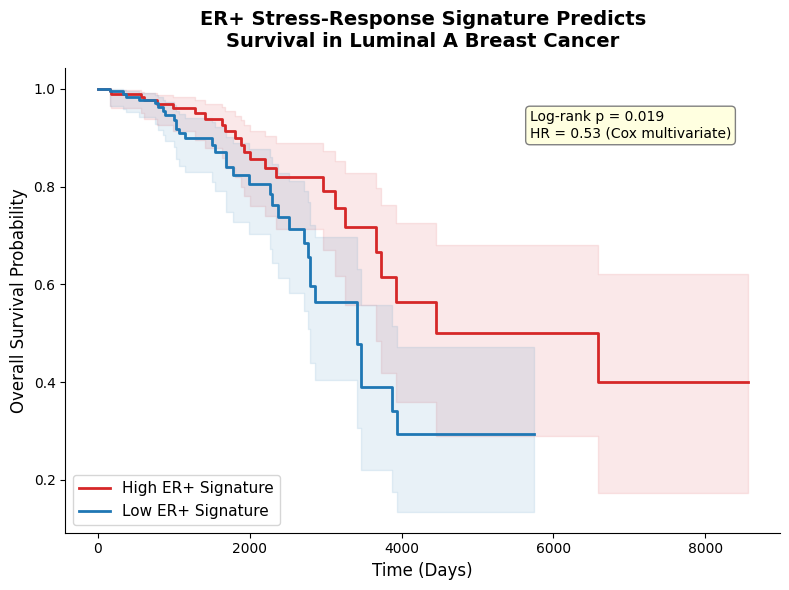

Saved.


In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

kmf_luma_high.plot_survival_function(
    ax=ax, 
    color='#D62728',
    linewidth=2,
    ci_show=True,
    ci_alpha=0.1)

kmf_luma_low.plot_survival_function(
    ax=ax, 
    color='#1F77B4',
    linewidth=2,
    ci_show=True,
    ci_alpha=0.1)

ax.set_title('ER+ Stress-Response Signature Predicts\nSurvival in Luminal A Breast Cancer', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Overall Survival Probability', fontsize=12)
ax.legend(fontsize=11, frameon=True)

# Add significance annotation
ax.annotate(f'Log-rank p = 0.019\nHR = 0.53 (Cox multivariate)',
            xy=(0.65, 0.85),
            xycoords='axes fraction',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='lightyellow', 
                     edgecolor='gray'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Figure1_KM_LumA_publication.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved.')


In [51]:
# Load METABRIC expression
metabric_expr = pd.read_csv('/Users/mac/Downloads/brca_metabric/data_mrna_illumina_microarray.txt', 
                             sep='\t', index_col=0)

# Load METABRIC clinical data
metabric_clinical = pd.read_csv('/Users/mac/Downloads/brca_metabric/data_clinical_patient.txt', 
                                 sep='\t', comment='#')

print('Expression shape:', metabric_expr.shape)
print('Clinical shape:', metabric_clinical.shape)
print('\nClinical columns:', metabric_clinical.columns.tolist()[:20])


Expression shape: (20603, 1981)
Clinical shape: (2509, 24)

Clinical columns: ['PATIENT_ID', 'LYMPH_NODES_EXAMINED_POSITIVE', 'NPI', 'CELLULARITY', 'CHEMOTHERAPY', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HORMONE_THERAPY', 'INFERRED_MENOPAUSAL_STATE', 'SEX', 'INTCLUST', 'AGE_AT_DIAGNOSIS', 'OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE', 'THREEGENE', 'VITAL_STATUS', 'LATERALITY', 'RADIO_THERAPY']


In [52]:
print(metabric_clinical['CLAUDIN_SUBTYPE'].value_counts())
print('\nOS_STATUS values:')
print(metabric_clinical['OS_STATUS'].value_counts())


CLAUDIN_SUBTYPE
LumA           700
LumB           475
Her2           224
claudin-low    218
Basal          209
Normal         148
NC               6
Name: count, dtype: int64

OS_STATUS values:
OS_STATUS
1:DECEASED    1144
0:LIVING       837
Name: count, dtype: int64


In [53]:
# Convert OS_STATUS to numeric
metabric_clinical['OS'] = (metabric_clinical['OS_STATUS'] == '1:DECEASED').astype(int)

# Check
print(metabric_clinical['OS'].value_counts())
print(metabric_clinical['OS_MONTHS'].describe())


OS
0    1365
1    1144
Name: count, dtype: int64
count    1981.000000
mean      125.244271
std        76.111772
min         0.000000
25%        60.866667
50%       116.466667
75%       185.133333
max       355.200000
Name: OS_MONTHS, dtype: float64


In [54]:
# Transpose expression so patients are rows
metabric_expr_T = metabric_expr.T
metabric_expr_T.index.name = 'PATIENT_ID'
metabric_expr_T = metabric_expr_T.reset_index()

# Merge
metabric_merged = metabric_expr_T.merge(
    metabric_clinical[['PATIENT_ID', 'OS', 'OS_MONTHS', 
                        'CLAUDIN_SUBTYPE', 'AGE_AT_DIAGNOSIS']],
    on='PATIENT_ID', how='inner')

print('Merged shape:', metabric_merged.shape)
print(metabric_merged['CLAUDIN_SUBTYPE'].value_counts())


Merged shape: (1980, 20608)
CLAUDIN_SUBTYPE
LumA           700
LumB           475
Her2           224
claudin-low    218
Basal          209
Normal         148
NC               6
Name: count, dtype: int64


In [55]:
# Check ER+ genes in METABRIC
missing_metabric = [g for g in erplus_genes_unique if g not in metabric_merged.columns]
print('Missing genes:', missing_metabric)
print('Found:', len(erplus_genes_unique) - len(missing_metabric), 'out of', len(erplus_genes_unique))


Missing genes: []
Found: 12 out of 12


METABRIC LumA patients: 700


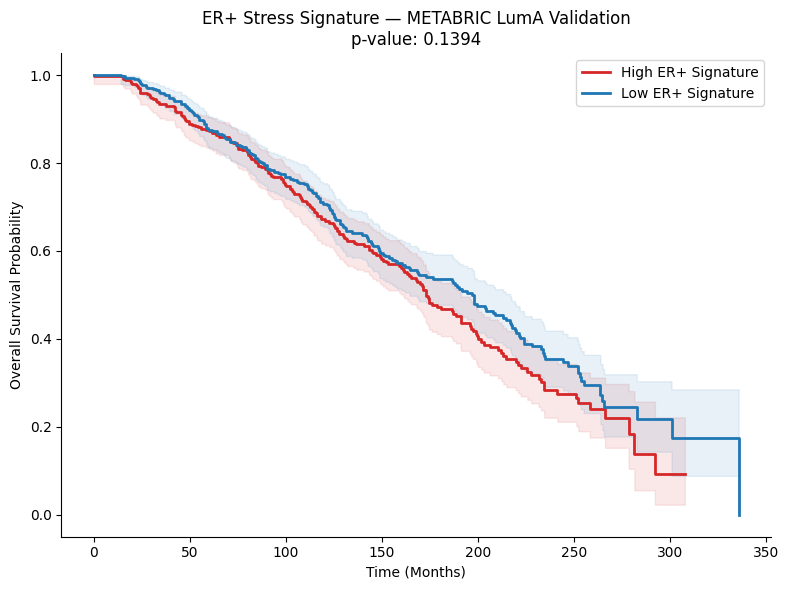

METABRIC Log-rank p-value: 0.1394


In [56]:
# Filter LumA patients
metabric_luma = metabric_merged[metabric_merged['CLAUDIN_SUBTYPE'] == 'LumA'].copy()
print('METABRIC LumA patients:', len(metabric_luma))

# Score
luma_expr_m = metabric_luma[erplus_genes_unique]
luma_scores_m = zscore(luma_expr_m, axis=0)
metabric_luma['erplus_score'] = pd.Series(
    luma_scores_m.mean(axis=1), index=metabric_luma.index)

# Split
metabric_luma_high = metabric_luma[metabric_luma['erplus_score'] > metabric_luma['erplus_score'].median()]
metabric_luma_low = metabric_luma[metabric_luma['erplus_score'] <= metabric_luma['erplus_score'].median()]

# KM curve
kmf_m_high = KaplanMeierFitter()
kmf_m_low = KaplanMeierFitter()
kmf_m_high.fit(metabric_luma_high['OS_MONTHS'], event_observed=metabric_luma_high['OS'], label='High ER+ Signature')
kmf_m_low.fit(metabric_luma_low['OS_MONTHS'], event_observed=metabric_luma_low['OS'], label='Low ER+ Signature')

fig, ax = plt.subplots(figsize=(8, 6))
kmf_m_high.plot_survival_function(ax=ax, color='#D62728', linewidth=2, ci_alpha=0.1)
kmf_m_low.plot_survival_function(ax=ax, color='#1F77B4', linewidth=2, ci_alpha=0.1)

results_m = logrank_test(
    metabric_luma_high['OS_MONTHS'], metabric_luma_low['OS_MONTHS'],
    event_observed_A=metabric_luma_high['OS'],
    event_observed_B=metabric_luma_low['OS'])

ax.set_title(f'ER+ Stress Signature — METABRIC LumA Validation\np-value: {results_m.p_value:.4f}')
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Overall Survival Probability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Figure2_KM_METABRIC_LumA_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'METABRIC Log-rank p-value: {results_m.p_value:.4f}')


In [57]:
low_threshold = metabric_luma['erplus_score'].quantile(0.33)
high_threshold = metabric_luma['erplus_score'].quantile(0.67)

metabric_luma_high = metabric_luma[metabric_luma['erplus_score'] >= high_threshold]
metabric_luma_low = metabric_luma[metabric_luma['erplus_score'] <= low_threshold]

print('High group:', len(metabric_luma_high))
print('Low group:', len(metabric_luma_low))


High group: 231
Low group: 231


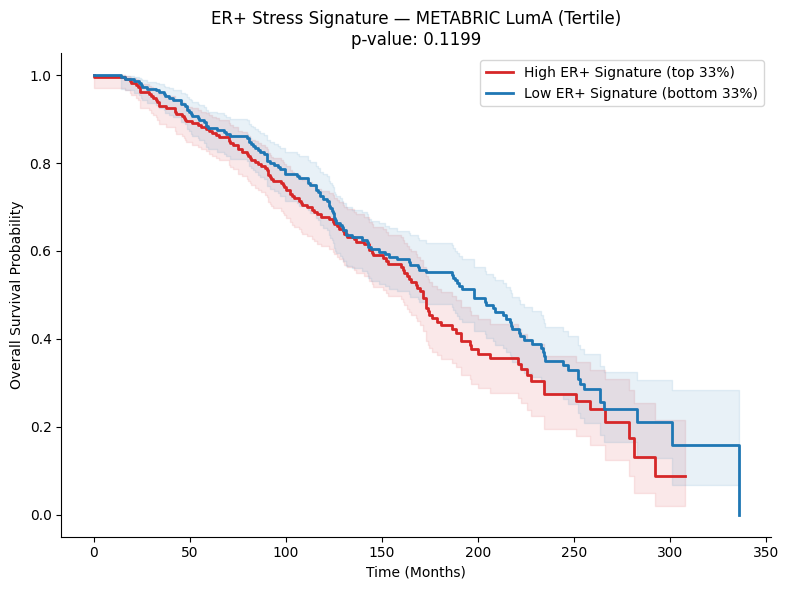

METABRIC tertile p-value: 0.1199


In [58]:
kmf_m_high = KaplanMeierFitter()
kmf_m_low = KaplanMeierFitter()
kmf_m_high.fit(metabric_luma_high['OS_MONTHS'], 
               event_observed=metabric_luma_high['OS'], 
               label='High ER+ Signature (top 33%)')
kmf_m_low.fit(metabric_luma_low['OS_MONTHS'], 
              event_observed=metabric_luma_low['OS'], 
              label='Low ER+ Signature (bottom 33%)')

fig, ax = plt.subplots(figsize=(8, 6))
kmf_m_high.plot_survival_function(ax=ax, color='#D62728', linewidth=2, ci_alpha=0.1)
kmf_m_low.plot_survival_function(ax=ax, color='#1F77B4', linewidth=2, ci_alpha=0.1)

results_m_tertile = logrank_test(
    metabric_luma_high['OS_MONTHS'], metabric_luma_low['OS_MONTHS'],
    event_observed_A=metabric_luma_high['OS'],
    event_observed_B=metabric_luma_low['OS'])

ax.set_title(f'ER+ Stress Signature — METABRIC LumA (Tertile)\np-value: {results_m_tertile.p_value:.4f}')
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Overall Survival Probability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Figure2_KM_METABRIC_LumA_tertile.png', dpi=300)
plt.show()

print(f'METABRIC tertile p-value: {results_m_tertile.p_value:.4f}')


In [59]:
# Compare score distributions
print('TCGA LumA ER+ scores:')
print(luma['erplus_score'].describe())

print('\nMETABRIC LumA ER+ scores:')
print(metabric_luma['erplus_score'].describe())


TCGA LumA ER+ scores:
count    4.330000e+02
mean    -3.025550e-17
std      4.082025e-01
min     -1.016835e+00
25%     -2.694892e-01
50%      1.574345e-03
75%      2.517721e-01
max      1.467322e+00
Name: erplus_score, dtype: float64

METABRIC LumA ER+ scores:
count    7.000000e+02
mean     3.108624e-17
std      3.414071e-01
min     -1.043526e+00
25%     -2.278749e-01
50%     -3.085830e-02
75%      1.998767e-01
max      1.275954e+00
Name: erplus_score, dtype: float64


In [60]:
print('METABRIC subtype column unique values:')
print(metabric_clinical['CLAUDIN_SUBTYPE'].unique())
print('\nMETABRIC THREEGENE column:')
print(metabric_clinical['THREEGENE'].value_counts())


METABRIC subtype column unique values:
['claudin-low' 'LumA' 'LumB' 'Normal' nan 'Her2' 'Basal' 'NC']

METABRIC THREEGENE column:
THREEGENE
ER+/HER2- Low Prolif     640
ER+/HER2- High Prolif    617
ER-/HER2-                309
HER2+                    198
Name: count, dtype: int64


In [62]:
print('PKM2 in TCGA LumA:')
print(luma['PKM2'].describe())

print('\nPKM2 in METABRIC LumA:')
print(metabric_luma['PKM2'].describe())


PKM2 in TCGA LumA:
count    433.000000
mean      14.192673
std        0.592150
min       11.772400
25%       13.822100
50%       14.239100
75%       14.564100
max       16.606800
Name: PKM2, dtype: float64

PKM2 in METABRIC LumA:


KeyError: 'PKM2'

In [63]:
# Search for PKM in METABRIC
pkm_matches = [col for col in metabric_merged.columns if 'PKM' in col]
print('PKM matches in METABRIC:', pkm_matches)

# Also check all our ER+ genes in METABRIC
for gene in erplus_genes_unique:
    if gene not in metabric_merged.columns:
        print(f'MISSING: {gene}')
    else:
        print(f'FOUND: {gene}')


PKM matches in METABRIC: ['PKM', 'PKMYT1', 'VCPKMT']
FOUND: JUN
FOUND: CDKN1A
FOUND: IRF1
FOUND: GADD45B
FOUND: DDIT4
FOUND: ENO2
FOUND: HSPA5
FOUND: IER3
FOUND: BTG2
FOUND: CD44
FOUND: RHOB
FOUND: STC2


In [64]:
# Check which genes were actually used in METABRIC scoring
print('Genes in erplus_genes_unique:')
print(erplus_genes_unique)

print('\nWhich of these exist in METABRIC:')
for gene in erplus_genes_unique:
    if gene in metabric_merged.columns:
        print(f'FOUND: {gene}')
    else:
        print(f'MISSING: {gene}')


Genes in erplus_genes_unique:
['JUN', 'CDKN1A', 'IRF1', 'GADD45B', 'DDIT4', 'ENO2', 'HSPA5', 'IER3', 'BTG2', 'CD44', 'RHOB', 'STC2']

Which of these exist in METABRIC:
FOUND: JUN
FOUND: CDKN1A
FOUND: IRF1
FOUND: GADD45B
FOUND: DDIT4
FOUND: ENO2
FOUND: HSPA5
FOUND: IER3
FOUND: BTG2
FOUND: CD44
FOUND: RHOB
FOUND: STC2


In [65]:
# Check exact genes used in METABRIC
print('Genes in erplus_genes_unique:')
print(erplus_genes_unique)

print('\nChecking each in METABRIC:')
for gene in erplus_genes_unique:
    if gene in metabric_merged.columns:
        val = metabric_luma[gene].mean()
        print(f'FOUND: {gene} — mean expression: {val:.3f}')
    else:
        print(f'MISSING: {gene}')


Genes in erplus_genes_unique:
['JUN', 'CDKN1A', 'IRF1', 'GADD45B', 'DDIT4', 'ENO2', 'HSPA5', 'IER3', 'BTG2', 'CD44', 'RHOB', 'STC2']

Checking each in METABRIC:
FOUND: JUN — mean expression: 9.598
FOUND: CDKN1A — mean expression: 9.732
FOUND: IRF1 — mean expression: 8.945
FOUND: GADD45B — mean expression: 7.448
FOUND: DDIT4 — mean expression: 9.286
FOUND: ENO2 — mean expression: 7.666
FOUND: HSPA5 — mean expression: 8.541
FOUND: IER3 — mean expression: 10.052
FOUND: BTG2 — mean expression: 9.609
FOUND: CD44 — mean expression: 8.242
FOUND: RHOB — mean expression: 8.835
FOUND: STC2 — mean expression: 10.786


In [66]:
print('Checking each in TCGA LumA:')
for gene in erplus_genes_unique:
    if gene in luma.columns:
        val = luma[gene].mean()
        print(f'FOUND: {gene} — mean expression: {val:.3f}')
    else:
        print(f'MISSING: {gene}')


Checking each in TCGA LumA:
FOUND: JUN — mean expression: 11.800
FOUND: CDKN1A — mean expression: 10.733
FOUND: IRF1 — mean expression: 10.016
FOUND: GADD45B — mean expression: 9.973
FOUND: DDIT4 — mean expression: 10.638
FOUND: ENO2 — mean expression: 9.405
FOUND: HSPA5 — mean expression: 13.911
FOUND: IER3 — mean expression: 11.116
FOUND: BTG2 — mean expression: 12.467
FOUND: CD44 — mean expression: 13.161
FOUND: RHOB — mean expression: 13.286
FOUND: STC2 — mean expression: 12.781


In [67]:
# Check TCGA phenotype for treatment columns
hormone_cols = [col for col in phenotype.columns if 'hormone' in col.lower() or 'therapy' in col.lower() or 'tamoxifen' in col.lower()]
print(hormone_cols)


['additional_pharmaceutical_therapy', 'additional_radiation_therapy', 'radiation_therapy', 'targeted_molecular_therapy']


In [68]:
print(phenotype['targeted_molecular_therapy'].value_counts())
print(phenotype['additional_pharmaceutical_therapy'].value_counts())


targeted_molecular_therapy
YES    597
NO      47
Name: count, dtype: int64
additional_pharmaceutical_therapy
YES    56
NO     35
Name: count, dtype: int64


In [69]:
print('MKI67 in TCGA:', 'MKI67' in merged_clean.columns)
print('MKI67 LumA expression:')
print(luma['MKI67'].describe())


MKI67 in TCGA: True
MKI67 LumA expression:
count    433.000000
mean      10.040859
std        1.197470
min        4.111200
25%        9.507800
50%       10.202600
75%       10.805000
max       13.165500
Name: MKI67, dtype: float64


Pearson correlation: 0.0039, p=0.9362
Spearman correlation: -0.0833, p=0.0835


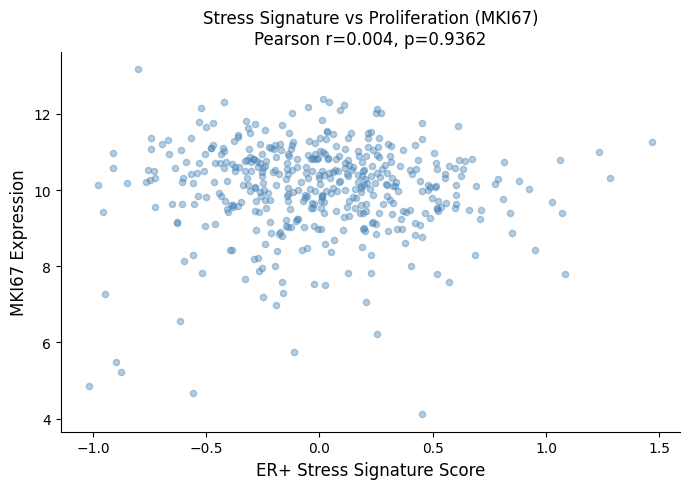

In [70]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# Correlation between ER+ stress score and MKI67
corr_pearson, p_pearson = pearsonr(luma['erplus_score'], luma['MKI67'])
corr_spearman, p_spearman = spearmanr(luma['erplus_score'], luma['MKI67'])

print(f'Pearson correlation: {corr_pearson:.4f}, p={p_pearson:.4f}')
print(f'Spearman correlation: {corr_spearman:.4f}, p={p_spearman:.4f}')

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(luma['erplus_score'], luma['MKI67'], 
           alpha=0.4, color='steelblue', s=20)
ax.set_xlabel('ER+ Stress Signature Score', fontsize=12)
ax.set_ylabel('MKI67 Expression', fontsize=12)
ax.set_title(f'Stress Signature vs Proliferation (MKI67)\nPearson r={corr_pearson:.3f}, p={p_pearson:.4f}', 
             fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('MKI67_correlation.png', dpi=300)
plt.show()


In [71]:
# Check all treatment columns in merged_clean for LumA patients
treatment_cols = [col for col in merged_clean.columns 
                  if any(word in col.lower() for word in 
                  ['hormone', 'therapy', 'treatment', 'tamoxifen', 
                   'pharma', 'radiation', 'chemo'])]
print(treatment_cols)

# Check values in each
for col in treatment_cols:
    print(f'\n{col}:')
    print(luma[col].value_counts())


[]


In [72]:
# Add hormone therapy to metabric_merged
metabric_merged = metabric_merged.merge(
    metabric_clinical[['PATIENT_ID', 'HORMONE_THERAPY']],
    on='PATIENT_ID',
    how='left')

metabric_luma = metabric_merged[metabric_merged['CLAUDIN_SUBTYPE'] == 'LumA'].copy()
print(metabric_luma['HORMONE_THERAPY'].value_counts())


HORMONE_THERAPY
YES    477
NO     223
Name: count, dtype: int64


In [73]:
# Check METABRIC hormone therapy data in LumA
print(metabric_clinical['HORMONE_THERAPY'].value_counts())

# Check it exists in metabric_luma
print('\nIn LumA patients:')
print(metabric_luma['HORMONE_THERAPY'].value_counts())


HORMONE_THERAPY
YES    1216
NO      764
Name: count, dtype: int64

In LumA patients:
HORMONE_THERAPY
YES    477
NO     223
Name: count, dtype: int64


In [74]:
# Score METABRIC LumA
luma_expr_m = metabric_luma[erplus_genes_unique]
luma_scores_m = zscore(luma_expr_m, axis=0)
metabric_luma['erplus_score'] = pd.Series(
    luma_scores_m.mean(axis=1), index=metabric_luma.index)

# Create high/low groups
median_score = metabric_luma['erplus_score'].median()
metabric_luma['score_group'] = metabric_luma['erplus_score'].apply(
    lambda x: 'High' if x > median_score else 'Low')

# Create 4 combined groups
metabric_luma['combined_group'] = metabric_luma['score_group'] + '_' + metabric_luma['HORMONE_THERAPY']

print(metabric_luma['combined_group'].value_counts())


combined_group
High_YES    252
Low_YES     225
Low_NO      125
High_NO      98
Name: count, dtype: int64


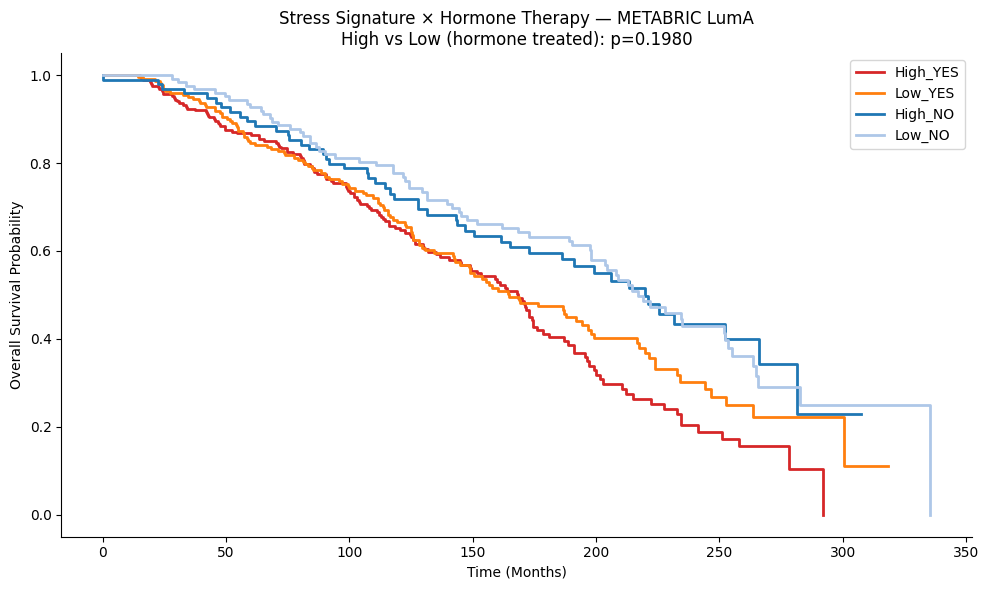

High_YES vs Low_YES p-value: 0.1980


In [75]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'High_YES': '#D62728',
    'Low_YES': '#FF7F0E', 
    'High_NO': '#1F77B4',
    'Low_NO': '#AEC7E8'
}

for group, color in colors.items():
    mask = metabric_luma['combined_group'] == group
    kmf = KaplanMeierFitter()
    kmf.fit(
        metabric_luma[mask]['OS_MONTHS'],
        event_observed=metabric_luma[mask]['OS'],
        label=group)
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=False)

# Log-rank test — High_YES vs Low_YES (hormone therapy patients only)
high_yes = metabric_luma[metabric_luma['combined_group'] == 'High_YES']
low_yes = metabric_luma[metabric_luma['combined_group'] == 'Low_YES']

results_combined = logrank_test(
    high_yes['OS_MONTHS'], low_yes['OS_MONTHS'],
    event_observed_A=high_yes['OS'],
    event_observed_B=low_yes['OS'])

ax.set_title(f'Stress Signature × Hormone Therapy — METABRIC LumA\nHigh vs Low (hormone treated): p={results_combined.p_value:.4f}')
ax.set_xlabel('Time (Months)')
ax.set_ylabel('Overall Survival Probability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('KM_METABRIC_hormone_therapy.png', dpi=300)
plt.show()

print(f'High_YES vs Low_YES p-value: {results_combined.p_value:.4f}')
